## Imports and Functions

In [4]:
import numpy as np
from pynwb import read_nwb
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image

from pathlib import Path

from CSE583_humanSayMonkeyDo.load_config import get_data_paths

from CSE583_humanSayMonkeyDo.data_loading import(
    get_nwbs,
    get_neural_data,
    get_trial_times,
    get_kinematics,
)

from CSE583_humanSayMonkeyDo.visualization import(
    plot_lda_results,
    plot_firing_rate_heatmap,
)

from CSE583_humanSayMonkeyDo.data_formatting import(
    get_windowed_pos_chunk,
    get_chunk_spikes_binned_windowed,
)

from CSE583_humanSayMonkeyDo.analysis import(
    get_movement_onset_times,
    train_lda_classifier,
)

# Load Human Data

In [5]:
#Get paths to human NWB files
human_paths = get_nwbs('human', 2)

#Load first NWB file
h_nwbfile = read_nwb(human_paths[0])
#Visualize entries
h_nwbfile



root pynwb.file.NWBFile at 0x6040829104
Fields:
  acquisition: {
    ElectricalSeries <class 'pynwb.ecephys.ElectricalSeries'>
  }
  devices: {
    auto_device <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    auto_group <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  epochs: epochs <class 'pynwb.epoch.TimeIntervals'>
  file_create_date: [datetime.datetime(2019, 6, 19, 13, 7, 30, 430300, tzinfo=tzoffset(None, -25200))]
  identifier: GP33_B30
  institution: University of California, San Francisco
  intervals: {
    epochs <class 'pynwb.epoch.TimeIntervals'>,
    invalid_times <class 'pynwb.epoch.TimeIntervals'>,
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  invalid_times: invalid_times <class 'pynwb.epoch.TimeIntervals'>
  lab: Chang Lab
  session_description: GP33_B30
  session_id: GP33_B30
  session_start_time: 1900-01-01 08:00:00+00:00
  subject: subject pynwb.file.Subject at 0x6040826752
Fields:
  species: Homo sapiens
  subject_id: GP33

  timestamps_reference_time: 1900-01-01 08:00:00+00:00
  trials: trials <class 'pynwb.epoch.TimeIntervals'>

# Visualize Data

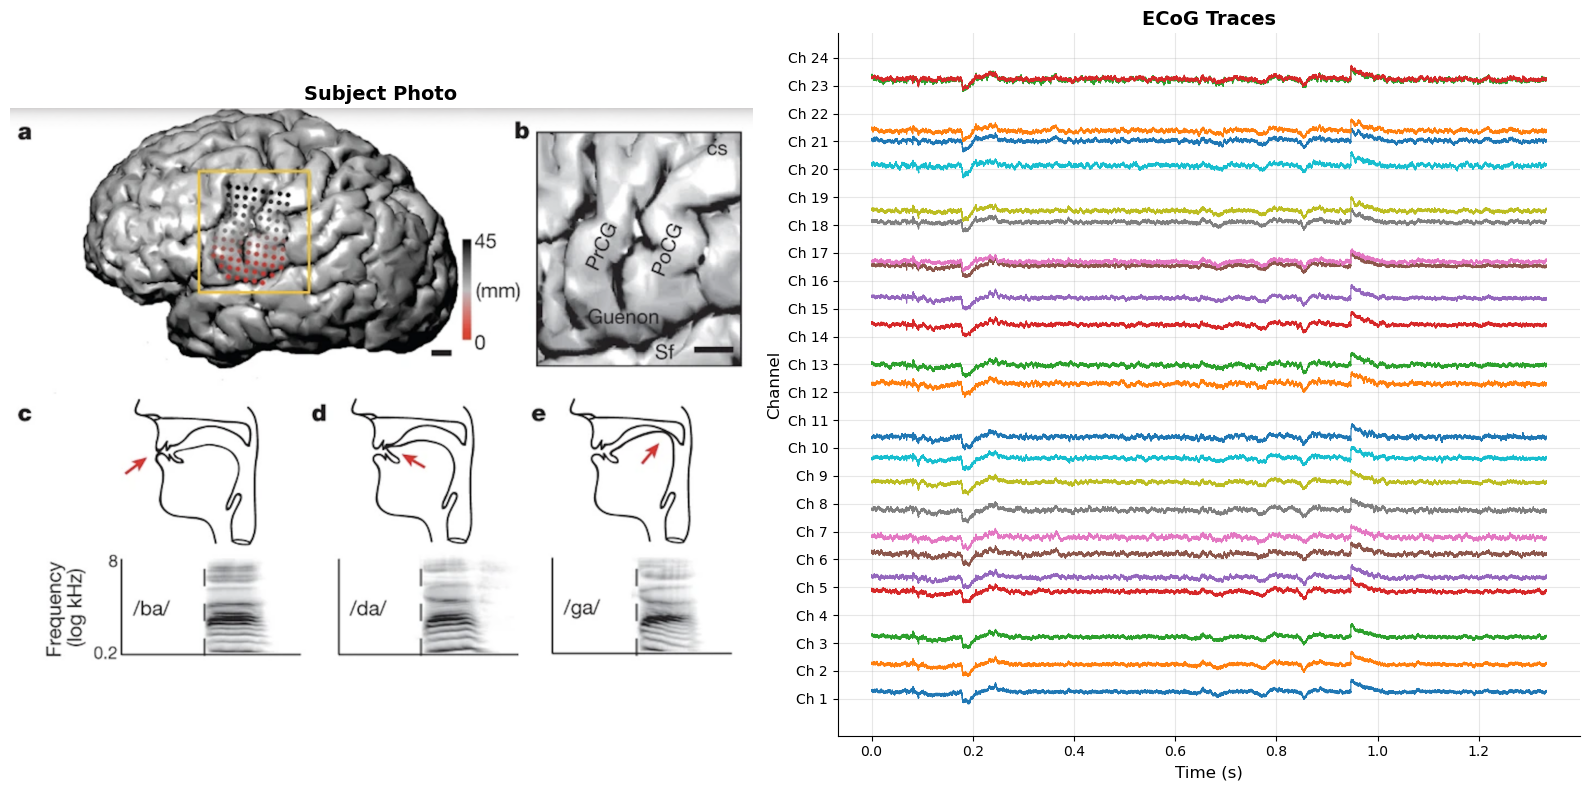

In [6]:
data_paths = get_data_paths()

# Load your photo
photo_path = Path( data_paths['root'].parent, 'doc/ref_pic/human_data.png')  # Replace with your image path
photo = Image.open(photo_path)


ecog_data =  h_nwbfile.acquisition['ElectricalSeries'].data[120000:160000,0:24].T*1000

sampling_rate = 30000  # Hz
time = np.arange(ecog_data.shape[1]) / sampling_rate

# Create figure with custom layout
fig = plt.figure(figsize=(16, 8))
gs = GridSpec(1, 2, width_ratios=[1, 1], figure=fig)

# Left panel: Photo
ax_photo = fig.add_subplot(gs[0])
ax_photo.imshow(photo)
ax_photo.axis('off')
ax_photo.set_title('Subject Photo', fontsize=14, fontweight='bold')

# Right panel: ECoG traces
ax_ecog = fig.add_subplot(gs[1])

# Plot each channel with offset for visibility
n_channels = ecog_data.shape[0]
offset = np.max(np.abs(ecog_data)) * 0.75  # Spacing between traces

for i in range(n_channels):
    ax_ecog.plot(time, ecog_data[i] + i * offset, linewidth=0.8, label=f'Ch {i+1}')

ax_ecog.set_xlabel('Time (s)', fontsize=12)
ax_ecog.set_ylabel('Channel', fontsize=12)
ax_ecog.set_title('ECoG Traces', fontsize=14, fontweight='bold')
ax_ecog.set_yticks(np.arange(n_channels) * offset)
ax_ecog.set_yticklabels([f'Ch {i+1}' for i in range(n_channels)])
ax_ecog.grid(True, alpha=0.3)
ax_ecog.spines['top'].set_visible(False)
ax_ecog.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Get Kinematics

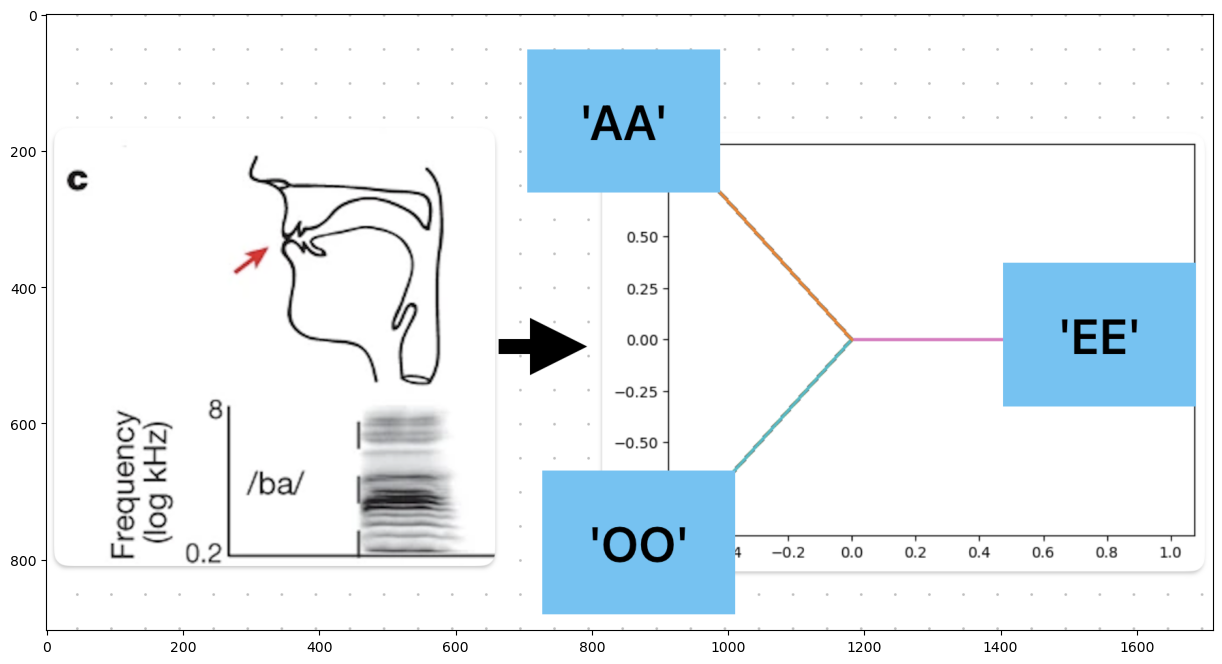

In [9]:

nwbfile = h_nwbfile
kinematics, timestamps, metadata = get_kinematics(nwbfile)
# Load your photo
photo_path = Path( data_paths['root'].parent, 'doc/ref_pic/human_get_kinematics.png')  # Replace with your image path
photo = Image.open(photo_path)

fig = plt.figure(figsize=(16, 8))
plt.imshow(photo)


# Get Trial Times

Index(['trial_start', 'go', 'trial_end'], dtype='object')


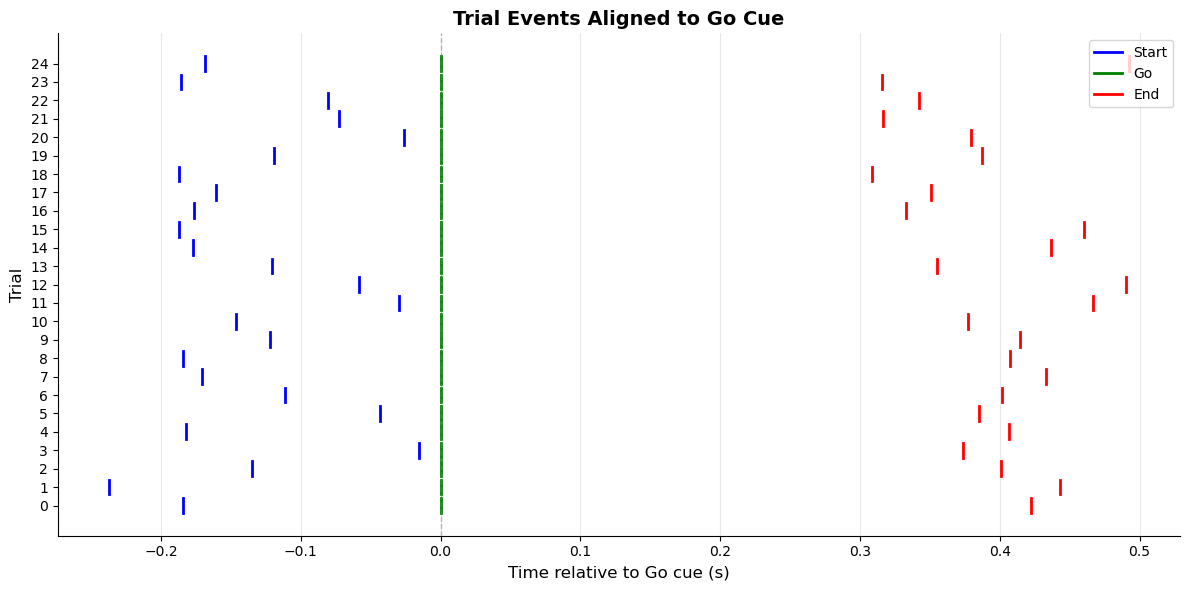

In [16]:

trial_times, metadata = get_trial_times(nwbfile)

# Select 5 trials
n_trials = 25
trials_to_plot = trial_times.head(n_trials)
print(trial_times.keys())
# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

# For each trial, align to go time (go = 0)
for idx, trial in trials_to_plot.iterrows():
    trial_id = idx
    go_time = trial['go']
    
    # Calculate relative times (centered at go)
    start_rel = trial['trial_start'] - go_time
    go_rel = 0  # go time is always 0 in aligned coordinates
    end_rel = trial['trial_end'] - go_time
    
    # Plot vertical lines
    ax.plot([start_rel, start_rel], [idx - 0.4, idx + 0.4], 'b-', linewidth=2, label='Start' if idx == 0 else '')
    ax.plot([go_rel, go_rel], [idx - 0.4, idx + 0.4], 'g-', linewidth=2, label='Go' if idx == 0 else '')
    ax.plot([end_rel, end_rel], [idx - 0.4, idx + 0.4], 'r-', linewidth=2, label='End' if idx == 0 else '')

# Formatting
ax.set_xlabel('Time relative to Go cue (s)', fontsize=12)
ax.set_ylabel('Trial', fontsize=12)
ax.set_title('Trial Events Aligned to Go Cue', fontsize=14, fontweight='bold')
ax.set_yticks(range(n_trials))
#ax.set_yticklabels([f'Trial {int(trial["id"])}' for _, trial in trials_to_plot.iterrows()])
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


# Load Neural Data And Visualize

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Neural Population Firing Rate'}, xlabel='Time Bin', ylabel='Unit Number'>)

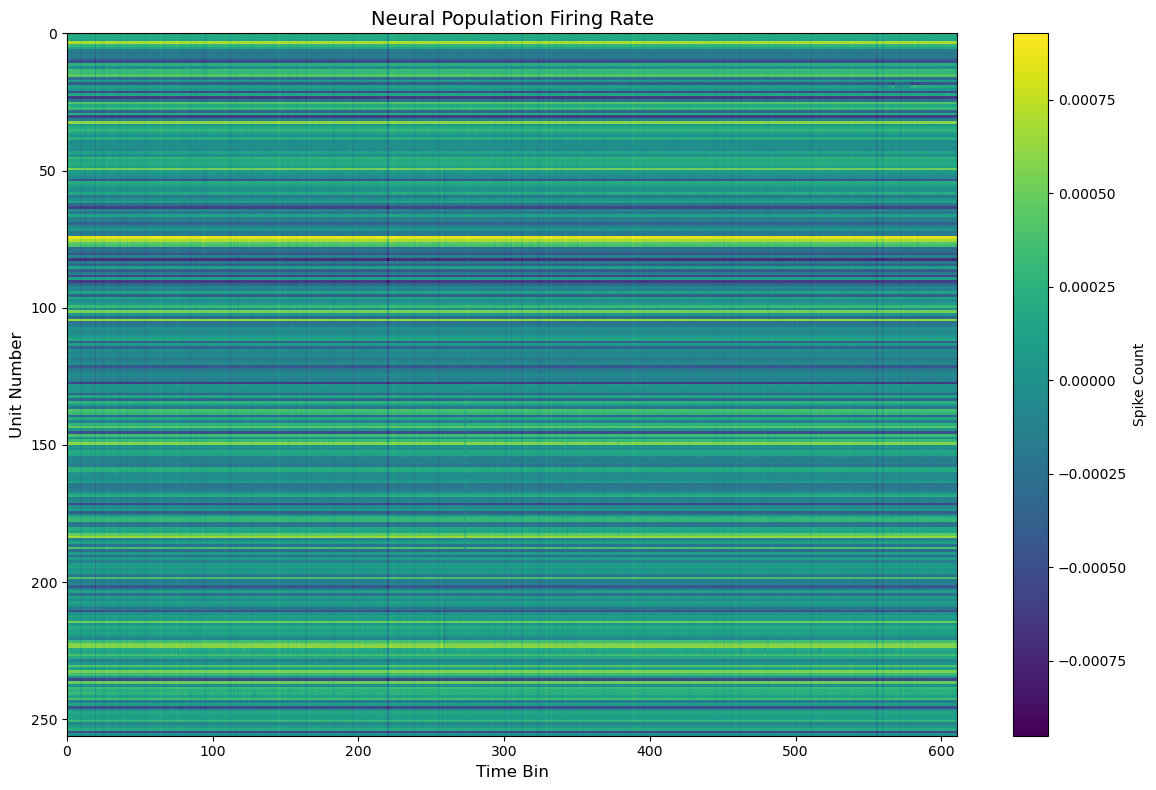

In [23]:
go_cue_times = trial_times['go']
window = [0.2, 0.5]  # 200 ms before to 500 ms after go cue

#cursor_pos_chunks = get_windowed_pos_chunk(kinematics, timestamps, go_cue_times, window)

neural_data, metadata = get_neural_data(nwbfile, go_cue_times, window)


avg_spike_rates = np.mean(neural_data,axis=0)


plot_firing_rate_heatmap(avg_spike_rates, time_axis=None, bin_size=None,
                              figsize=(12, 8), cmap='viridis', 
                              vmin=None, vmax=None, title=None)


# Analysis: Movement Detection

In [24]:
window = [0.0, 0.2]
movement_spike_data, metadata = get_neural_data(nwbfile, go_cue_times, window, bin_size=0.01)

window = [-0.2, 0.0]
stationary_spike_data, metadata = get_neural_data(nwbfile, go_cue_times, window, bin_size=0.01)


(1224,)
(610, 256, 1224)
Data shape: (1224, 156160)
Labels shape: (1224,)
Class distribution: 0=612, 1=612

=== LDA Classification Results ===
Training Accuracy: 0.979
Test Accuracy: 0.910
Cross-validation Accuracy: 0.903 (+/- 0.028)

CV Scores: [0.85306122 0.89387755 0.93061224 0.92244898 0.91393443]

=== Test Set Confusion Matrix ===
[[109  14]
 [  8 114]]

=== Classification Report ===
              precision    recall  f1-score   support

     Class 0       0.93      0.89      0.91       123
     Class 1       0.89      0.93      0.91       122

    accuracy                           0.91       245
   macro avg       0.91      0.91      0.91       245
weighted avg       0.91      0.91      0.91       245



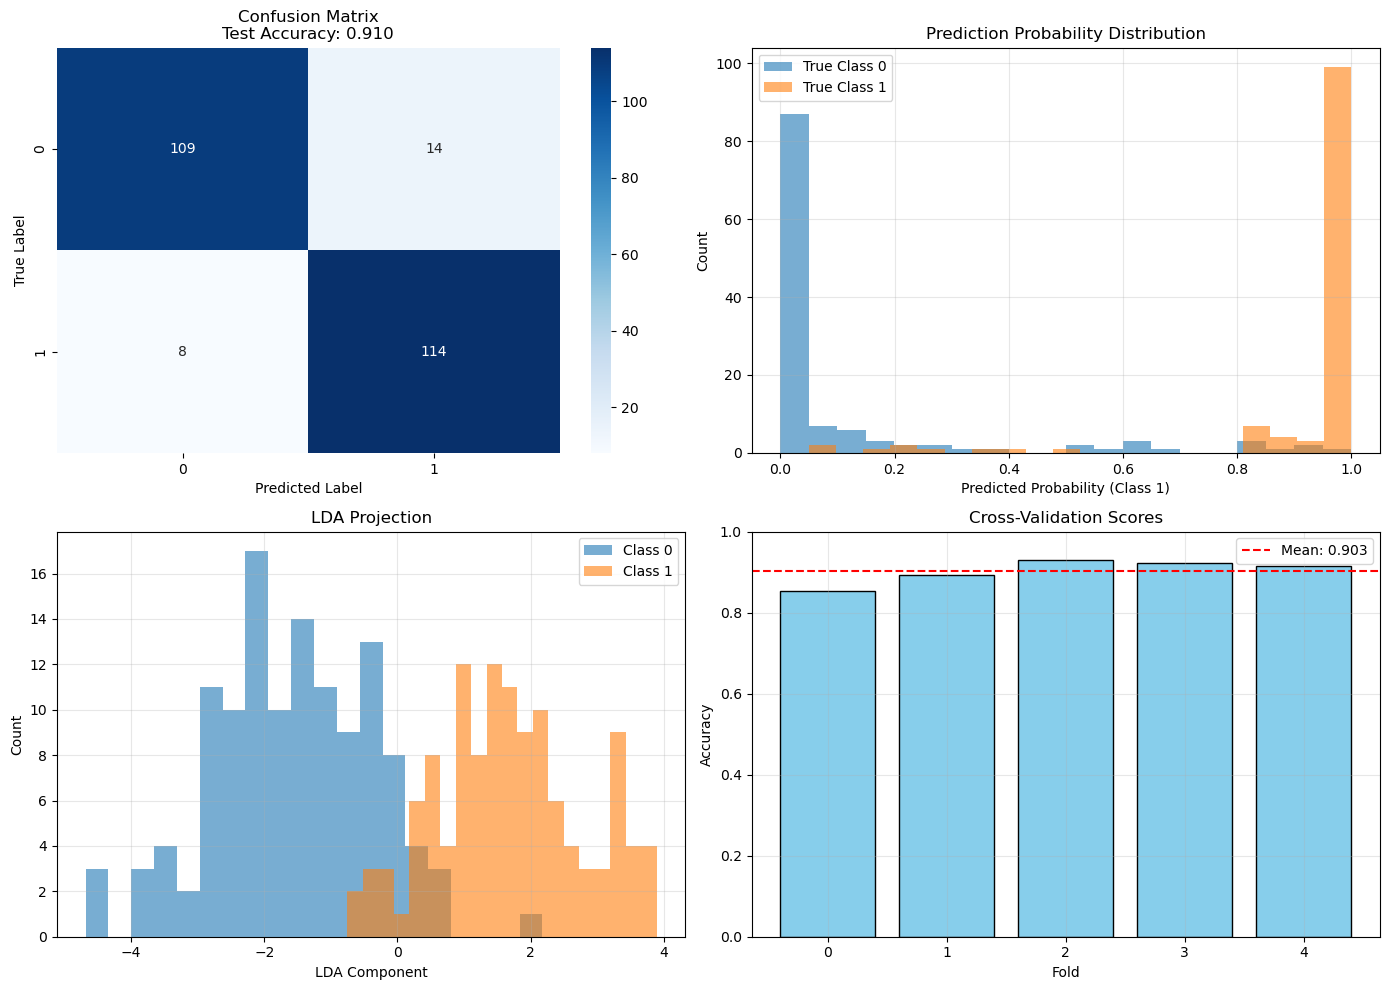

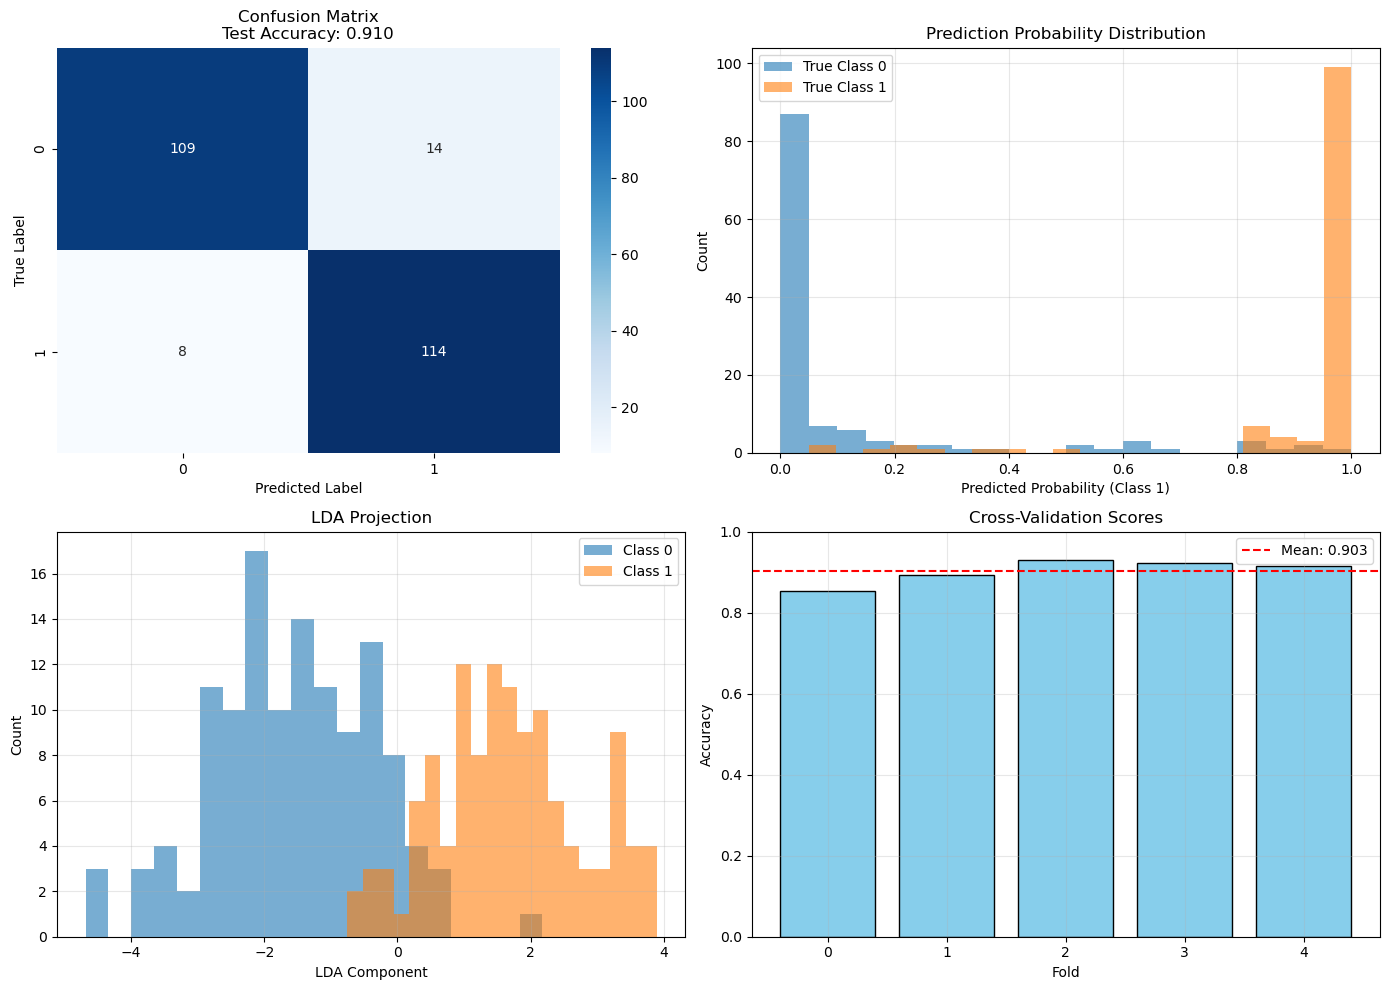

In [25]:



data = movement_spike_data
move_category = np.ones(movement_spike_data.shape[2], dtype=int)  # All ones for movement


data = np.concatenate([data, stationary_spike_data], axis=2)
move_category = np.concatenate([move_category,
                           np.zeros(stationary_spike_data.shape[2], dtype=int)])  # All zeros for stationary


print(move_category.shape)
print(data.shape)

lda, results = train_lda_classifier(data.T, move_category)

# Visualize
plot_lda_results(results)
